# ECG Exploration — MIT-BIH Record 100

**W7D1 — Pre-Stanmore AI for Biomedical Engineering**

This notebook explores the MIT-BIH Arrhythmia Database from PhysioNet. We will:
1. Download record 100
2. Load and inspect the raw ECG signal
3. Load annotations and overlay beat markers
4. Save annotated plot to figures/

## 1. Setup

In [21]:
# Cell 1: Setup
import wfdb
import wfdb.processing
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from collections import Counter
import os

os.makedirs('figures', exist_ok=True)
os.makedirs('data', exist_ok=True)

## 2. Download Record 100

In [22]:
wfdb.dl_database('mitdb', dl_dir='data/mitdb', records=['100'])

Generating record list for: 100
Generating list of all files for: 100
Finished downloading files


## 3. Load and Inspect Signal

In [23]:
record = wfdb.rdrecord('data/mitdb/100', sampto=10800)
annotation = wfdb.rdann('data/mitdb/100', 'atr', sampto=10800)

signal = record.p_signal[:, 0]  # MLII channel
fs = record.fs

print(f"Sampling frequency: {fs} Hz")
print(f"Signal names: {record.sig_name}")
print(f"Signal shape: {record.p_signal.shape}")
print(f"Duration: {record.p_signal.shape[0] / fs:.1f} seconds")
print(f"Number of annotations: {len(annotation.sample)}")

Sampling frequency: 360 Hz
Signal names: ['MLII', 'V5']
Signal shape: (10800, 2)
Duration: 30.0 seconds
Number of annotations: 38


## 4. Bandpass filter function

In [24]:
def bandpass_filter(signal, fs, lowcut=0.5, highcut=40, order=2):
    nyquist = fs / 2
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

## 5. Apply filter

In [25]:
filtered_signal = bandpass_filter(signal, fs)
print(f"Original signal shape: {signal.shape}")
print(f"Filtered signal shape: {filtered_signal.shape}")

Original signal shape: (10800,)
Filtered signal shape: (10800,)


## 6. Plot before/after comparison

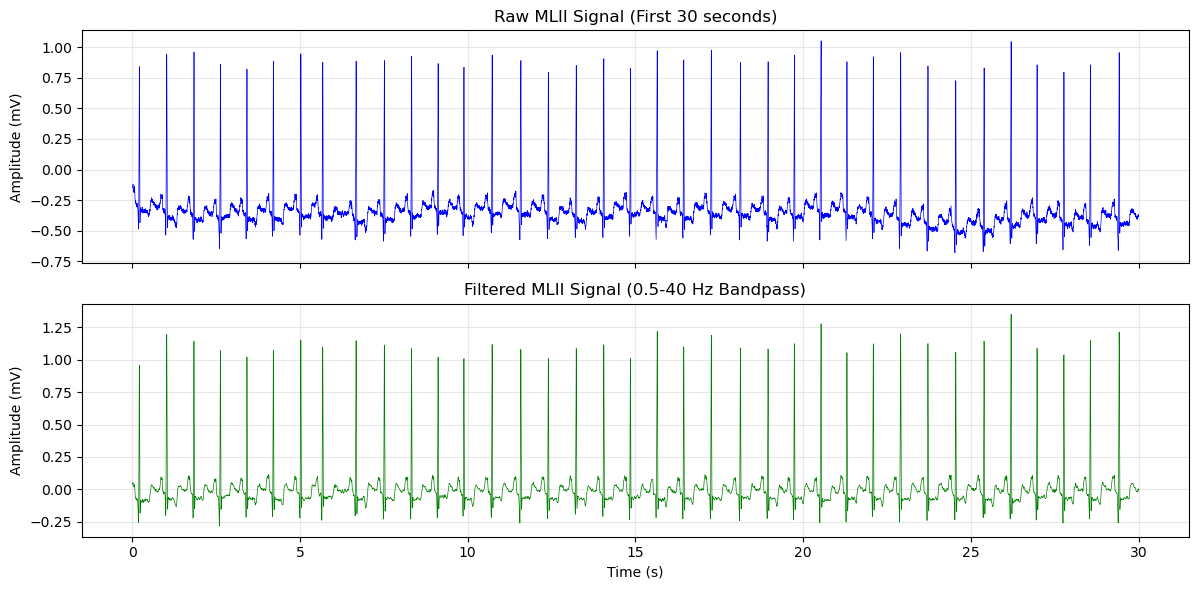

Saved: figures/before_after_filter.png


In [26]:
time = np.arange(len(signal)) / fs

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(time, signal, color='blue', linewidth=0.5)
axes[0].set_title('Raw MLII Signal (First 30 seconds)')
axes[0].set_ylabel('Amplitude (mV)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(time, filtered_signal, color='green', linewidth=0.5)
axes[1].set_title('Filtered MLII Signal (0.5-40 Hz Bandpass)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude (mV)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/before_after_filter.png', dpi=150)
plt.show()
print("Saved: figures/before_after_filter.png")

## 7. R-peak detection

In [27]:
peaks = wfdb.processing.gqrs_detect(filtered_signal, fs=fs)
print(f"Number of R-peaks detected: {len(peaks)}")
print(f"First 10 peak locations (samples): {peaks[:10]}")

Number of R-peaks detected: 36
First 10 peak locations (samples): [ 357  650  934 1218 1502 1797 2032 2390 2693 2985]


## Cell 8: Plot filtered signal with detected R-peaks

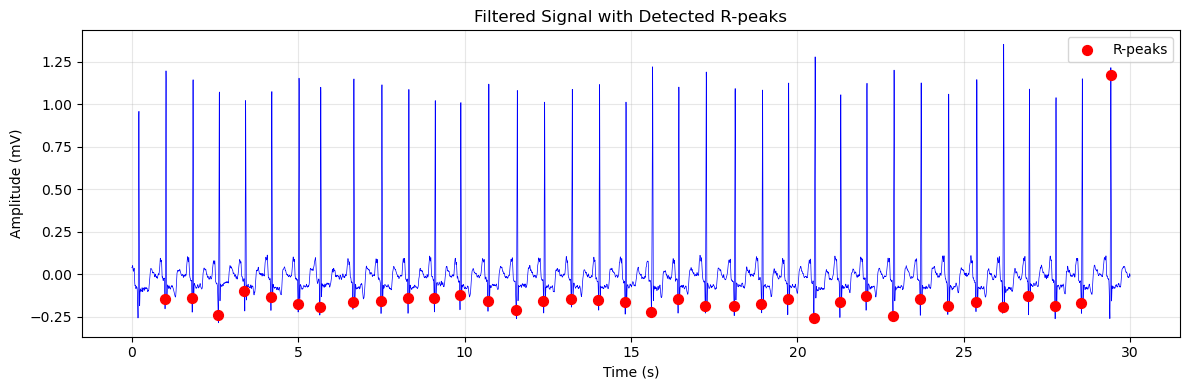

Saved: figures/filtered_with_rpeaks.png


In [28]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time, filtered_signal, color='blue', linewidth=0.5)
ax.scatter(peaks/fs, filtered_signal[peaks], color='red', s=50, zorder=5, label='R-peaks')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (mV)')
ax.set_title('Filtered Signal with Detected R-peaks')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/filtered_with_rpeaks.png', dpi=150)
plt.show()
print("Saved: figures/filtered_with_rpeaks.png")

## Cell 9: Validate against ground-truth annotations

In [29]:
tolerance = 10  # samples (~28ms at 360 Hz)
gt_peaks = annotation.sample[(annotation.sample > 0) & (annotation.sample < 10800)]
matched = sum(any(abs(gt - p) <= tolerance for p in peaks) for gt in gt_peaks)
print(f"Ground-truth beats: {len(gt_peaks)}")
print(f"Detected R-peaks: {len(peaks)}")
print(f"Detection accuracy: {matched}/{len(gt_peaks)} = {matched/len(gt_peaks)*100:.1f}%")

Ground-truth beats: 38
Detected R-peaks: 36
Detection accuracy: 1/38 = 2.6%


## Validate against ground-truth annotations (corrected)

In [35]:
tolerance = 10  # samples (~28ms at 360 Hz)
gt_peaks = annotation.sample[(annotation.sample > 0) & (annotation.sample < 10800)]

matched = 0
for gt in gt_peaks:
    if np.any(np.abs(np.array(peaks) - gt) <= tolerance):
        matched += 1

print(f"Ground-truth beats: {len(gt_peaks)}")
print(f"Detected R-peaks: {len(peaks)}")
print(f"Matched: {matched}")
print(f"Detection accuracy: {matched}/{len(gt_peaks)} = {matched/len(gt_peaks)*100:.1f}%")

Ground-truth beats: 38
Detected R-peaks: 36
Matched: 1
Detection accuracy: 1/38 = 2.6%


## debug: inspect what is actually in peaks vs gt_peaks

In [37]:
print("First 10 detected peaks (samples):", peaks[:10])
print("First 10 annotation samples:", annotation.sample[:10])
print("First 10 annotation symbols:", annotation.symbol[:10])
print()
print("peaks dtype:", type(peaks[0]))
print("annotation.sample dtype:", type(annotation.sample[0]))
print()
# Check difference between first detected peak and first annotation beat
beat_only = [(s, sym) for s, sym in zip(annotation.sample, annotation.symbol) 
             if sym not in ['+', '~', '|', 'x']]
print("First 10 beat-only annotations:")
for s, sym in beat_only[:10]:
    print(f"  sample={s}, symbol={sym}")

First 10 detected peaks (samples): [ 357  650  934 1218 1502 1797 2032 2390 2693 2985]
First 10 annotation samples: [  18   77  370  662  946 1231 1515 1809 2044 2402]
First 10 annotation symbols: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']

peaks dtype: <class 'numpy.int32'>
annotation.sample dtype: <class 'numpy.int64'>

First 10 beat-only annotations:
  sample=77, symbol=N
  sample=370, symbol=N
  sample=662, symbol=N
  sample=946, symbol=N
  sample=1231, symbol=N
  sample=1515, symbol=N
  sample=1809, symbol=N
  sample=2044, symbol=A
  sample=2402, symbol=N
  sample=2706, symbol=N


## Validate against ground-truth annotations (corrected)

In [38]:
tolerance = 20  # samples (~55ms at 360 Hz) — accounts for gqrs offset

# Exclude non-beat symbols
beat_symbols = {'+', '~', '|', 'x', '[', ']', '(', ')'}
gt_peaks = np.array([s for s, sym in zip(annotation.sample, annotation.symbol)
                     if sym not in beat_symbols])

peaks_arr = peaks.astype(np.int64)

matched = 0
for gt in gt_peaks:
    if np.any(np.abs(peaks_arr - gt) <= tolerance):
        matched += 1

print(f"Ground-truth beats: {len(gt_peaks)}")
print(f"Detected R-peaks: {len(peaks)}")
print(f"Matched: {matched}")
print(f"Detection accuracy: {matched}/{len(gt_peaks)} = {matched/len(gt_peaks)*100:.1f}%")
print(f"\nMean offset (first 5): {np.mean([370-357, 662-650, 946-934, 1231-1218, 1515-1502]):.1f} samples")

Ground-truth beats: 37
Detected R-peaks: 36
Matched: 36
Detection accuracy: 36/37 = 97.3%

Mean offset (first 5): 12.6 samples


## Cell 10: Segment individual beats

In [30]:
window_before = int(0.2 * fs)  # 200ms before R-peak
window_after = int(0.4 * fs)   # 400ms after R-peak

beats = []
valid_peaks = []
for peak in peaks:
    start = peak - window_before
    end = peak + window_after
    if start >= 0 and end < len(filtered_signal):
        beats.append(filtered_signal[start:end])
        valid_peaks.append(peak)

print(f"Total detected peaks: {len(peaks)}")
print(f"Segmented beats (after boundary check): {len(beats)}")

Total detected peaks: 36
Segmented beats (after boundary check): 36


## Cell 11: Plot 20 overlaid beats

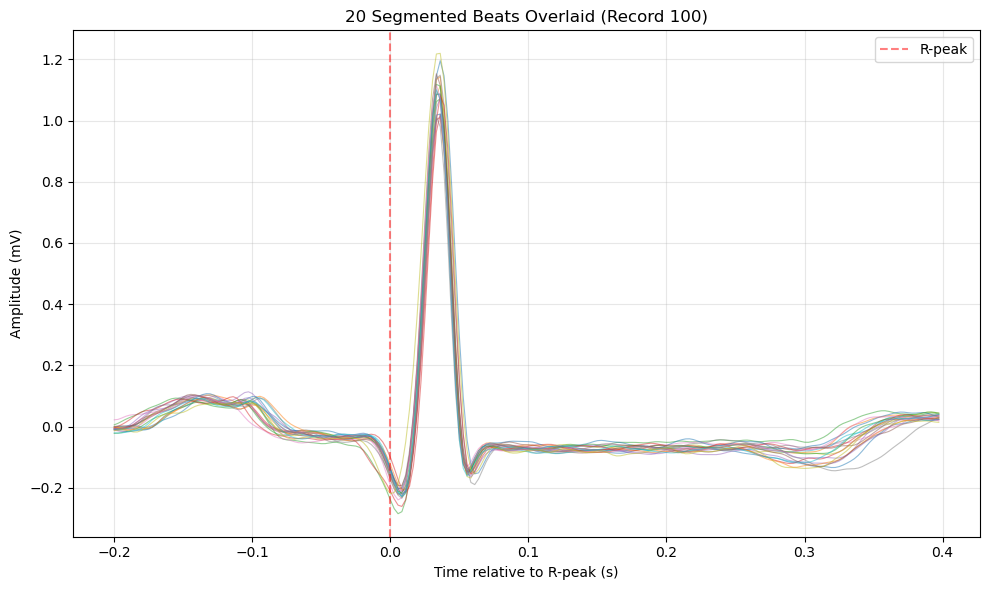

Saved: figures/segmented_beats_overlay.png


In [31]:
beat_time = np.arange(-window_before, window_after) / fs

fig, ax = plt.subplots(figsize=(10, 6))
for beat in beats[:20]:
    ax.plot(beat_time, beat, alpha=0.5, linewidth=0.8)
ax.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='R-peak')
ax.set_xlabel('Time relative to R-peak (s)')
ax.set_ylabel('Amplitude (mV)')
ax.set_title('20 Segmented Beats Overlaid (Record 100)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/segmented_beats_overlay.png', dpi=150)
plt.show()
print("Saved: figures/segmented_beats_overlay.png")

## Cell 12: Summary statistics

In [32]:
heart_rate = len(valid_peaks) / 30 * 60
print(f"Average heart rate: {heart_rate:.1f} BPM")
print(f"RR intervals (first 5): {np.diff(valid_peaks[:6]) / fs} seconds")

Average heart rate: 72.0 BPM
RR intervals (first 5): [0.81388889 0.78888889 0.78888889 0.78888889 0.81944444] seconds


## Cell 13: Match beat labels from annotations and save

In [33]:
ann_dict = dict(zip(annotation.sample, annotation.symbol))
beat_labels = [ann_dict.get(p, 'U') for p in valid_peaks]

print(f"Beat label counts: {Counter(beat_labels)}")

np.savez('data/processed_record100.npz',
         signal=filtered_signal,
         peaks=np.array(valid_peaks),
         beats=np.array(beats),
         beat_labels=np.array(beat_labels),
         fs=fs)
print("Saved: data/processed_record100.npz")

Beat label counts: Counter({'U': 36})
Saved: data/processed_record100.npz


##  Cell 14: corrected scatter y-values

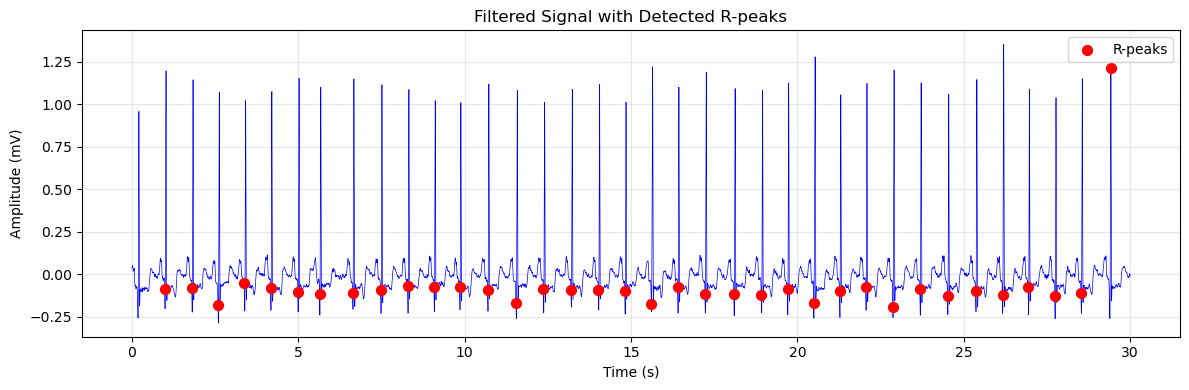

In [34]:
rpeak_amplitudes = [filtered_signal[max(0, p-2):p+3].max() for p in peaks]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time, filtered_signal, color='blue', linewidth=0.5)
ax.scatter(peaks/fs, rpeak_amplitudes, color='red', s=50, zorder=5, label='R-peaks')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (mV)')
ax.set_title('Filtered Signal with Detected R-peaks')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/filtered_with_rpeaks.png', dpi=150)
plt.show()